In [1]:
!pwd

/Users/anshulchiranth/Desktop/Strike/Voice Experiments


In [2]:
import numpy as np

In [3]:
from pathlib import Path

base_dir = Path.cwd()

input_dir = base_dir / "DQ Lakewood Voice Samples"
processed_dir = base_dir / "Processed DQ Lakewood Voice Samples"
output_dir = base_dir / "To Be Embedded Lakewood Voice Samples"

In [4]:
processed_dir.mkdir(parents = True, exist_ok = True)
output_dir.mkdir(parents = True, exist_ok = True)

In [5]:
from utils import prepare_audio_for_embedding, decode_audio, preprocess_audio, save_audio

/opt/anaconda3/envs/voice_id_env/lib/python3.11/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [10]:
from tqdm import tqdm

raw_input_files = [f for f in input_dir.rglob("*")]
print(f"Found {len(raw_input_files)} raw input files.")

processed_audio_samples = []

for i, file_path in enumerate(raw_input_files):
    file_name = str(raw_input_files[i])[len(str(input_dir))+1:]
    audio, sr = decode_audio(file_path)
    processed_audio_sample = preprocess_audio(audio, sr)
    output_path = save_audio(audio, sr, processed_dir / f"Processed_{file_name}")
    print(f"Saved file to {output_path}")

Found 6 raw input files.
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Processed DQ Lakewood Voice Samples/Processed_Amber.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Processed DQ Lakewood Voice Samples/Processed_Anna.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Processed DQ Lakewood Voice Samples/Processed_Emma.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Processed DQ Lakewood Voice Samples/Processed_Daililah.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Processed DQ Lakewood Voice Samples/Processed_Courtney.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Processed DQ Lakewood Voice Samples/Processed_Conner.wav


In [11]:
for file_path in raw_input_files:
    print(file_path)

/Users/anshulchiranth/Desktop/Strike/Voice Experiments/DQ Lakewood Voice Samples/Amber.wav
/Users/anshulchiranth/Desktop/Strike/Voice Experiments/DQ Lakewood Voice Samples/Anna.wav
/Users/anshulchiranth/Desktop/Strike/Voice Experiments/DQ Lakewood Voice Samples/Emma.wav
/Users/anshulchiranth/Desktop/Strike/Voice Experiments/DQ Lakewood Voice Samples/Daililah.wav
/Users/anshulchiranth/Desktop/Strike/Voice Experiments/DQ Lakewood Voice Samples/Courtney.wav
/Users/anshulchiranth/Desktop/Strike/Voice Experiments/DQ Lakewood Voice Samples/Conner.wav


In [15]:
processed_files = [f for f in processed_dir.rglob("*") if f.is_file()]

print(f"Found {len(processed_files)} audio files")

for processed_file in tqdm(processed_files):
    processed_path = prepare_audio_for_embedding(processed_file, output_dir)


Found 6 audio files


100%|██████████| 6/6 [00:00<00:00, 455.13it/s]


In [6]:
import torch
import nemo.collections.asr as nemo_asr

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

# Pretrained TitaNet Large speaker verification model
speaker_model = nemo_asr.models.EncDecSpeakerLabelModel.from_pretrained(
    model_name="nvidia/speakerverification_en_titanet_large"
).to(device)

speaker_model.eval()

/opt/anaconda3/envs/voice_id_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:numexpr.utils:NumExpr defaulting to 12 threads.
[NeMo W 2026-02-13 12:16:05 nemo_logging:405] Megatron num_microbatches_calculator not found, using Apex version.
W0213 12:16:05.778000 32446 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
INFO:nv_one_logger.exporter.export_config_manager:Final configuration contains 0 exporter(s)
[NeMo W 2026-02-13 12:16:07 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /manifests/combined_fisher_swbd_voxceleb12_libris

device: mps
[NeMo I 2026-02-13 12:16:07 nemo_logging:393] PADDING: 16
[NeMo I 2026-02-13 12:16:07 nemo_logging:393] Model EncDecSpeakerLabelModel was successfully restored from /Users/anshulchiranth/.cache/huggingface/hub/models--nvidia--speakerverification_en_titanet_large/snapshots/0dc382f40121a5fbd34db10a2bb04d826c2be6a8/speakerverification_en_titanet_large.nemo.


EncDecSpeakerLabelModel(
  (loss): AngularSoftmaxLoss()
  (eval_loss): AngularSoftmaxLoss()
  (_accuracy): TopKClassificationAccuracy()
  (preprocessor): AudioToMelSpectrogramPreprocessor(
    (featurizer): FilterbankFeatures()
  )
  (encoder): ConvASREncoder(
    (encoder): Sequential(
      (0): JasperBlock(
        (mconv): ModuleList(
          (0): MaskedConv1d(
            (conv): Conv1d(80, 80, kernel_size=(3,), stride=(1,), padding=(1,), groups=80, bias=False)
          )
          (1): MaskedConv1d(
            (conv): Conv1d(80, 1024, kernel_size=(1,), stride=(1,), bias=False)
          )
          (2): BatchNorm1d(1024, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (3): SqueezeExcite(
            (fc): Sequential(
              (0): Linear(in_features=1024, out_features=128, bias=False)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=128, out_features=1024, bias=False)
            )
            (gap): AdaptiveAvgPool1d(

In [7]:
emb_dir = base_dir / "Lakewood Embeddings"
emb_dir.mkdir(parents = True, exist_ok = True)

In [8]:
wav_files = sorted([p for p in output_dir.rglob("*.wav")])
print("WAV files found:", len(wav_files))
print("example:", wav_files[0] if wav_files else "None")

WAV files found: 6
example: /Users/anshulchiranth/Desktop/Strike/Voice Experiments/To Be Embedded Lakewood Voice Samples/Processed_Amber_converted.wav


In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm

rows = []
all_embs = {}  # {relative_path: embedding_vector}

with torch.no_grad():
    for wav_path in tqdm(wav_files):
        # NeMo provides get_embedding(path_to_wav) for speaker embeddings :contentReference[oaicite:3]{index=3}
        emb = speaker_model.get_embedding(str(wav_path))

        # Normalize output type -> 1D numpy array
        if isinstance(emb, torch.Tensor):
            emb_np = emb.detach().cpu().numpy()
        else:
            emb_np = np.asarray(emb)

        emb_np = np.squeeze(emb_np)  # ensure shape (D,)

        # Save one embedding per file
        rel = wav_path.relative_to(output_dir)
        out_path = emb_dir / rel.with_suffix(".npy")
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(out_path, emb_np)

        rows.append({
            "wav_path": str(wav_path),
            "embedding_path": str(out_path),
            "dim": int(emb_np.shape[0]),
        })
        all_embs[str(rel)] = emb_np

df = pd.DataFrame(rows)
df.to_csv(emb_dir / "index.csv", index=False)

# Also save a single archive for easy loading later
np.savez_compressed(emb_dir / "embeddings.npz", **all_embs)

print("Saved embeddings to:", emb_dir)
print(df.head())

100%|██████████| 6/6 [00:01<00:00,  3.93it/s]

Saved embeddings to: /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Lakewood Embeddings
                                            wav_path  \
0  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
1  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
2  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
3  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
4  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   

                                      embedding_path  dim  
0  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
1  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
2  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
3  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
4  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  


In [10]:
df

,wav_path,embedding_path,dim
0,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,192
1,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,192
2,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,192
3,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,192
4,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,192
5,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,/Users/anshulchiranth/Desktop/Strike/Voice Exp...,192


In [11]:
import numpy as np

def cosine(a, b, eps=1e-9):
    a = a / (np.linalg.norm(a) + eps)
    b = b / (np.linalg.norm(b) + eps)
    return float(np.dot(a, b))

# pick two embeddings from the npz
npz = np.load(emb_dir / "embeddings.npz")
keys = list(npz.keys())
print("num embeddings:", len(keys))

if len(keys) >= 2:
    e1, e2 = npz[keys[0]], npz[keys[1]]
    print("cosine similarity:", cosine(e1, e2))


num embeddings: 6
cosine similarity: 0.3602412939071655


Explained variance ratio: [0.31764412 0.23675883]


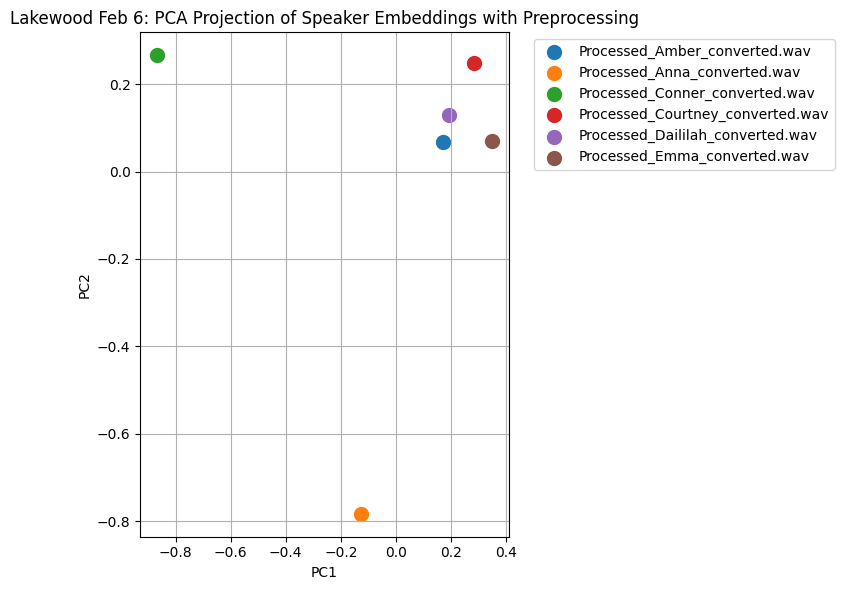

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load embeddings
npz = np.load("Lakewood Embeddings/embeddings.npz")
keys = list(npz.keys())
X = np.stack([npz[k] for k in keys])

# Optional: normalize for cosine geometry (recommended)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))

for i, label in enumerate(keys):
    plt.scatter(X_2d[i,0], X_2d[i,1], label=label.split("/")[-1], s=100)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Lakewood Feb 6: PCA Projection of Speaker Embeddings with Preprocessing")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
#plt.show()
plt.savefig("Lakewood Feb 6: PCA Projection of Speaker Embeddings with Preprocessing.png")


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
npz = np.load("Lakewood Embeddings/embeddings.npz")
keys = list(npz.keys())
X = np.stack([npz[k] for k in keys])

In [16]:
X

array([[-0.02568864,  0.01965071, -0.0068844 , ...,  0.00401326,
         0.01491076, -0.00334782],
       [ 0.00303736,  0.01704784,  0.00785479, ..., -0.00913476,
         0.00406567,  0.00699144],
       [-0.00094081,  0.03092666, -0.00122254, ..., -0.01329248,
         0.00887747, -0.03186886],
       [-0.0158407 ,  0.00888315, -0.02403246, ..., -0.01145344,
        -0.001333  ,  0.01159952],
       [-0.03187978,  0.01549986,  0.00070541, ...,  0.00412366,
         0.0026353 ,  0.01236213],
       [-0.02858011,  0.00490323, -0.01087857, ..., -0.00120911,
        -0.00427746,  0.02120702]], shape=(6, 192), dtype=float32)

In [22]:
sim = cosine_similarity(X)

In [19]:
sim_df = pd.DataFrame(cosine_similarity(X))

In [30]:
sim_df.rename(columns = {0: "Amber", 1: "Anna", 2: "Conner", 3: "Courtney", 4: "Daliliah", 5: "Emma"}, 
              index = {0: "Amber", 1: "Anna", 2: "Conner", 3: "Courtney", 4: "Daliliah", 5: "Emma"}, inplace = True)

In [31]:
sim_df

,Amber,Anna,Conner,Courtney,Daliliah,Emma
Amber,1.000000,0.360241,0.207598,0.479215,0.643034,0.412369
Anna,0.360241,1.000000,0.163650,0.244990,0.368945,0.302534
Conner,0.207598,0.163650,1.000000,0.122132,0.278639,0.101706
Courtney,0.479215,0.244990,0.122132,1.000000,0.472085,0.415168
Daliliah,0.643034,0.368945,0.278639,0.472085,1.000000,0.635492
Emma,0.412369,0.302534,0.101706,0.415168,0.635492,1.000000


In [1]:
import os, pathlib
print("cwd:", os.getcwd())
print("exists .env?", pathlib.Path(".env").exists())
print("exists .gitignore?", pathlib.Path(".gitignore").exists())
print("files:", sorted([p.name for p in pathlib.Path(".").iterdir()])[:50])

cwd: /Users/anshulchiranth/Desktop/Strike/Voice Experiments
exists .env? True
exists .gitignore? True
files: ['.DS_Store', '.env', '.git', '.gitignore', '.ipynb_checkpoints', 'DQ Lakewood Voice Samples', 'DQ Sanford Voice Samples', 'Ground Truth Embeddings', 'Julian_George.ipynb', 'Lakewood Embeddings', 'Lakewood Feb 6: PCA Projection of Speaker Embeddings with Preprocessing.png', 'PCA Projection of Speaker Embeddings with Preprocessing.png', 'Processed DQ Lakewood Voice Samples', 'Processed DQ Sanford Voice Samples', 'Processed Ground Truths', 'Processed Transaction Clips', 'Raw Ground Truths', 'Sample Transactions', 'Sanford Embeddings', 'To Be Embedded Ground Truths', 'To Be Embedded Lakewood Voice Samples', 'To Be Embedded Transactions', 'Transaction Embeddings', 'Unclipped Processed Transactions', 'Voice ID Experiments.ipynb', 'WhisperX Experiments.ipynb', '__pycache__', 'audio.srt', 'audio_2.srt', 'requirements.txt', 'utils.py']
